# 00 · Setup and orientation

Checks the kernel is the project venv, confirms the raw data is where the code expects it, and prints the constants the whole analysis is anchored to.

### How the notebooks chain together

| Notebook | Reads | Writes |
|---|---|---|
| `00_setup` | n/a |: |
| `01_ingest_clean` | `Accenture_Case_Comp_Data.zip` | `clean/*.parquet` |
| `02_data_quality` | `clean/*.parquet` | `clean/data_quality.csv`, figures |
| `03_angle1_cost` | `clean/analysis_df.parquet` | figures |
| `04_angle2_far` | `clean/analysis_df.parquet`, `monthly_exits` | figures |
| `05_angle3_silence` | `clean/analysis_df.parquet`, `engagement_long` | figures |

`01` does the heavy work once. The rest load parquet in under a second.

The plumbing (file discovery, type coercion, feature engineering) stays in
`src/etl.py`. Notebooks hold the *analysis*: the questions, the charts, and
the judgement calls. A cell over ~20 lines with no output worth reading belongs in `etl.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys

_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "etl.py").exists())
sys.path.insert(0, str(_root / "src"))

from nbinit import *   # etl, pd, np, plt, sns, project paths, chart theme, cache helpers

## Environment check

If `venv` below says `False`, the notebook is running against the system
Python. Fix it before going further: **Select Kernel → Python (NovaCorp)**,
or pick `.venv\Scripts\python.exe` directly.

In [2]:
import matplotlib
import platform

print(f"  python      {platform.python_version()}")
print(f"  executable  {sys.executable}")
print(f"  venv        {'.venv' in sys.executable}")
print()
for mod in [pd, np, matplotlib, sns]:
    print(f"  {mod.__name__:<12} {mod.__version__}")

import pyarrow
print(f"  {'pyarrow':<12} {pyarrow.__version__}")

  python      3.12.3
  executable  D:\Novacorp\GitHappens_AccentureXUSYDDatathon\.venv\Scripts\python.exe
  venv        True

  pandas       3.0.5
  numpy        2.5.2
  matplotlib   3.11.1
  seaborn      0.13.2
  pyarrow      25.0.1


## Paths

Resolved in `src/nbinit.py`, so they hold whatever the kernel's working
directory is.

In [3]:
for label, path in [("project root", ROOT), ("raw data zip", DATA_ZIP),
                    ("clean cache", CLEAN), ("figures", FIGURES)]:
    mark = "ok " if path.exists() else "MISSING"
    print(f"  {mark}  {label:<14} {path}")

  ok   project root   D:\Novacorp\GitHappens_AccentureXUSYDDatathon
  ok   raw data zip   D:\Novacorp\GitHappens_AccentureXUSYDDatathon\Accenture_Case_Comp_Data.zip
  ok   clean cache    D:\Novacorp\GitHappens_AccentureXUSYDDatathon\clean
  ok   figures        D:\Novacorp\GitHappens_AccentureXUSYDDatathon\figures


## The benchmark constants

Every dollar figure in this analysis traces back to one of these. They come
from the case brief (section 6) and the FY2025 annual report, not from the
dataset, which is exactly why the reconciliation in `02` matters.

In [4]:
benchmarks = pd.DataFrame([
    ("Replacement cost multiplier", f"{etl.REPLACEMENT_MULTIPLIER}x base salary", "brief §6"),
    ("Backfill rate", pct(etl.BACKFILL_RATE, 0), "brief §6"),
    ("Disengagement productivity loss", f"{pct(etl.DISENGAGEMENT_LOSS, 0)} of base salary p.a.", "brief §6"),
    ("Superannuation on-cost", pct(etl.SUPER_ONCOST, 1) + " (from 1 Jul 2025)", "legislated"),
    ("Agency fee", f"{pct(etl.AGENCY_FEE_RATE, 0)} of first-year base", "brief §6"),
    ("Direct hire benchmark", f"${etl.DIRECT_HIRE_BENCHMARK:,.0f} fully loaded", "brief §6"),
    ("Active headcount", f"{etl.AR_ACTIVE_HEADCOUNT:,}", "annual report FY25"),
    ("Voluntary attrition", pct(etl.AR_VOLUNTARY_ATTRITION), "annual report FY25"),
    ("Average base salary", f"${etl.AR_AVG_BASE_SALARY:,.0f}", "annual report FY25"),
    ("Survey response rate", pct(etl.AR_SURVEY_RESPONSE_RATE), "annual report FY25"),
    ("Departures", f"{etl.AR_DEPARTURES_FY25:,}", "annual report FY25"),
], columns=["constant", "value", "source"])

benchmarks

,constant,value,source
0,Replacement cost multiplier,1.5x base salary,brief §6
1,Backfill rate,85%,brief §6
2,Disengagement productivity loss,15% of base salary p.a.,brief §6
3,Superannuation on-cost,12.0% (from 1 Jul 2025),legislated
4,Agency fee,18% of first-year base,brief §6
5,Direct hire benchmark,"$5,500 fully loaded",brief §6
6,Active headcount,"12,003",annual report FY25
7,Voluntary attrition,10.4%,annual report FY25
8,Average base salary,"$128,000",annual report FY25
9,Survey response rate,81.7%,annual report FY25


## Finance's $42M, as published

Three components with a stated range each. Angle 1 asks whether the headcount
these ranges *imply* matches the headcount actually in the data.

In [5]:
pd.DataFrame([
    {"component": k.replace("_", " ").title(),
     "low_$m": lo / 1e6, "high_$m": hi / 1e6, "midpoint_$m": (lo + hi) / 2e6}
    for k, (lo, hi) in etl.COST_COMPONENTS.items()
])

,component,low_$m,high_$m,midpoint_$m
0,Regrettable Attrition,22.00,25.00,23.50
1,Disengagement,12.00,15.00,13.50
2,Hiring Inefficiency,4.00,6.00,5.00


## Chart theme

One palette, assigned in a fixed order and never cycled: slot 1 is the same
blue in every notebook, so a colour means the same thing on every slide. The
order is chosen to survive colour-vision deficiency on adjacent pairs; three
slots sit below the 3:1 contrast line against the surface, so charts that
reach them carry direct value labels rather than leaning on hue alone.

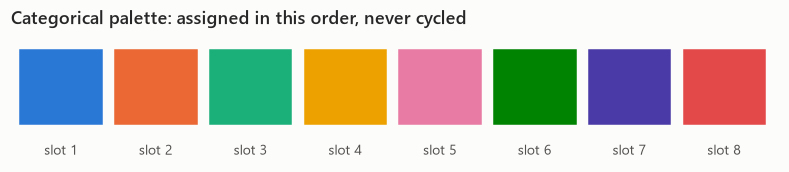

In [6]:
fig, ax = plt.subplots(figsize=(9, 1.4))
for i, colour in enumerate(SERIES):
    ax.add_patch(plt.Rectangle((i, 0), 0.86, 1, color=colour))
    ax.text(i + 0.43, -0.28, f"slot {i + 1}", ha="center", va="top",
            fontsize=9, color=INK["secondary"])
ax.set(xlim=(-0.1, len(SERIES)), ylim=(-0.5, 1.1))
ax.set_title("Categorical palette: assigned in this order, never cycled")
ax.axis("off")
plt.show()

## Next

Open **`01_ingest_clean.ipynb`** and run it top to bottom. It writes the
parquet cache that every other notebook reads.